In [1]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb -q
!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!apt-get update -q
!apt-get install -y google-chrome-stable -q
!pip install selenium webdriver-manager selenium_stealth -q

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 1 not upgraded.
Need to get 11.2 MB/141 MB of archives.
After this operation, 476 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatspi2.0-0 a

In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium_stealth import stealth
import time
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [3]:
class ParserException(Exception):
  pass

class WBparserException(ParserException):
  '''исключение при парсинге WB'''
  pass

class WBParser15secondsException(WBparserException):
    '''карточки не загрузились за 15 сек'''
    pass

class WBParserEmptyResultException(WBparserException):
    '''после очистки датафрейм оказался пустым'''
    pass

class WBParserNoDataException(WBparserException):
    '''парсер не нашел ни одной карточки на странице'''
    pass

In [14]:
class SeleniumParser:
  @classmethod
  def start_work(cls):
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

    stealth(driver, languages=["ru-RU", "ru"], vendor="Google Inc.", platform="Win32",
            webgl_vendor="Intel Inc.", renderer="Intel Iris OpenGL Engine", fix_hairline=True)

    return driver

class WBParser(SeleniumParser):
  objects = {}
  driver = SeleniumParser.start_work()

  def __init__(self, name: str):
    '''name - обычный поисковый запрос'''
    self.name = name
    name = name.replace(' ', '+')
    self.url = f'https://www.wildberries.ru/catalog/0/search.aspx?search={name}'

  def get_items(self, max_scrolls=10, pause=2.5, same_count_limit=3):
    '''скроллит страницу вб и возвращает суп'''
    driver = WBParser.driver
    driver.get(self.url)
    #time.sleep(5)

    last_count, same_count = 0, 0

    try:
        WebDriverWait(driver, 15).until(EC.presence_of_element_located((By.CSS_SELECTOR, "article.product-card")))
    except:
        raise WBParser15secondsException('Карточки не появились за 15 сек')

    driver.execute_script("window.scrollTo(0, 0)")
    # time.sleep(1)

    for i in range(max_scrolls):
        cards = driver.find_elements(By.CSS_SELECTOR, "article.product-card")
        current_count = len(cards)

        print(f"Прокрутка {i + 1}: {current_count} карточек")

        if current_count == last_count:
            same_count += 1
        else:
            same_count = 0

        if same_count >= same_count_limit:
            print("новые карточки перестали появляться")
            break

        last_count = current_count

        if cards:
            driver.execute_script("arguments[0].scrollIntoView({block: 'end'});", cards[-1])

        time.sleep(pause)

    soup = BeautifulSoup(driver.page_source, "html.parser")
    return soup

  def find_info(self, soup):
    '''достает название, бренд, цену и оценку из супа, возвращает список словарей'''
    cards = soup.find_all('article', class_='product-card')
    cards_info = []

    if len(cards) == 0:
      raise WBParserNoDataException(f'карточки не найдены для запроса {self.name}')

    for card in cards:
      name = card.find('span', class_='product-card__name')
      brand = card.find('span', class_='product-card__brand')
      price = card.find('ins', class_='price__lower-price')
      rating = card.find('span', class_='address-rate-mini')
      if name is not None:
        name_text = name.get_text()
        if name_text[:3] == ' / ':
          name_text = name_text[3:]
      else:
        name_text = None
      if brand is not None:
        brand_text = brand.get_text()
      else:
        brand_text = None
      if price is not None:
        price_text = price.get_text()
        price_text = int(price_text.replace('\xa0', '').replace('₽', '').strip())
      else:
        price_text = None
      if rating is not None:
        rating_text = rating.get_text()
        rating_text = float(rating_text.replace(',', '.'))
      else:
        rating_text = None
      cards_info.append({'название': name_text, 'бренд': brand_text, 'цена': price_text, 'оценка': rating_text})
    print(f'Найдено {len(cards_info)} объектов для запроса {self.name}')
    return cards_info

  def make_pandas(self, spisok):
    '''делает датафрейм из списка словарей, считает среднее и медиану'''
    df = pd.DataFrame(spisok)
    self.mean = df['цена'].mean()
    self.median = df['цена'].median()
    return df

  def clean_pandas(self, df, words: list):
    '''фильтрует по словам и убирает товары с рейтингом ниже 4.5 или без рейтинга

    филььтрация: фильтрует датафрейм и оставляет только строки где название содержит хоть одно слово из списка words'''
    pattern = '|'.join(words)
    df = df[df['название'].str.contains(pattern, case=False, na=False)]
    df = df[df['оценка'] >= 4.5]
    return df

  def make_graphics(self, df):
    '''четыре графика: гистограмма цен, violinplot и scatter цена vs рейтинг'''
    # palette = ['#2E86AB', '#E84855', '#3BB273']
    palette = ['HotPink', 'Indigo', '#7B68EE', '#FFD700']
    sns.set_style('white')

    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    fig.suptitle(f'Анализ цен: {self.name}', fontsize=15, fontweight='bold')

    #распределение цен всех
    axes[0].hist(df['цена'].dropna(), bins=15,
                 color=palette[0], edgecolor='white', alpha=0.85)
    axes[0].axvline(self.mean, color=palette[1], linestyle='--',
                    linewidth=2, label=f'среднее: {round(self.mean)} руб.')
    axes[0].axvline(self.median, color=palette[2], linestyle=':',
                    linewidth=2, label=f'медиана: {round(self.median)} руб.')
    axes[0].set_title('Распределение цен (все)')
    axes[0].set_xlabel('Цена (руб.)')
    axes[0].set_ylabel('Кол-во товаров')
    axes[0].legend()

    # распределение без выбросов
    q1 = df['цена'].quantile(0.25)
    q3 = df['цена'].quantile(0.75)
    iqr = q3 - q1
    if self.mean > self.median * 1.5:
        max_price = df['цена'].max()
        df_no_out = df[df['цена'] < max_price * 0.6]
    else:
        df_no_out = df[df['цена'] < q3 + 1.5 * iqr]

    axes[1].hist(df_no_out['цена'].dropna(), bins=15,
                color=palette[0], edgecolor='white', alpha=0.85)
    axes[1].axvline(self.mean, color=palette[1], linestyle='--',
                    linewidth=2, label=f'среднее: {round(self.mean)} руб.')
    axes[1].axvline(self.median, color=palette[2], linestyle=':',
                    linewidth=2, label=f'медиана: {round(self.median)} руб.')
    axes[1].set_title('Распределение цен (без выбросов)')
    axes[1].set_xlabel('Цена (руб.)')
    axes[1].set_ylabel('Кол-во товаров')
    axes[1].legend()

    #violinplot цен
    sns.violinplot(data=df, y='цена', color=palette[0],
                   inner='quartile', ax=axes[2])
    axes[2].axhline(self.mean, color=palette[1], linestyle='--',
                    linewidth=2, label=f'среднее: {round(self.mean)}')
    axes[2].axhline(self.median, color=palette[2], linestyle=':',
                    linewidth=2, label=f'медиана: {round(self.median)}')
    axes[2].set_title('Форма распределения цен')
    axes[2].set_ylabel('Цена (руб.)')
    axes[2].legend()

    # связь цены и рейтинга
    clean = df.dropna(subset=['цена', 'оценка'])
    axes[3].scatter(clean['оценка'], clean['цена'],
                    color=palette[0], alpha=0.5, edgecolors='white', linewidths=0.5)
    axes[3].set_title('Цена vs Рейтинг')
    axes[3].set_xlabel('Рейтинг')
    axes[3].set_ylabel('Цена (руб.)')

    plt.tight_layout()

  def make_everything(self, amount: int = 7, permitted_words: list | str = None, cleaning: bool = True):
    '''запускает весь код для одного товара - парсинг, датафрейм, очистка, графики'''
    if permitted_words is None:
      permitted_words = [self.name]
    elif ' ' not in permitted_words and isinstance(permitted_words, str):
      permitted_words = [permitted_words]
    else:
      permitted_words = ''
    soup = self.get_items(amount)
    spisok = self.find_info(soup)
    df = self.make_pandas(spisok)
    self._dirty_df = df
    if cleaning:
        df = self.clean_pandas(df, permitted_words)
    if df.empty:
        raise WBParserEmptyResultException(f'после очистки не осталось товаров для {self.name}')
    self.df = df
    self.make_graphics(df)

  @classmethod
  def create(cls, var_name: str, query: str, amount: int = 5, permitted_words: list | str = None, cleaning: bool = True):
    '''создает объект, запускает make_everything и сохраняет в objects'''
    obj = cls(query)
    obj.make_everything(amount, permitted_words, cleaning)
    cls.objects[var_name] = obj
    return obj

In [16]:
GR = {
    'пуходерка': 'пуходерка',
    'ножницы изогнутые': 'ножницы для груминга изогнутые',
    'фен': 'фен для груминга',
    'петля': 'ринговка для груминга',
    'когтерез': 'когтерез',
    'колтунорез': 'колтунорез',
    'ножницы прямые': 'прямые ножницы для груминга',
    'машинка': 'машинка для стрижки собак',
    'шампунь': 'шампунь для собак',
    'кондиционер': 'кондиционер для собак',
    'ножницы филировочные': 'филировочные ножницы',
    'лосьон': 'лосьон для собак для глаз',
    'ванна': 'ванна для груминга',
    'дешеддер': 'дешеддер',
    'стол' : 'стол для груминга',
}

PERMITTED = {
    'пуходерка': 'пуходерка',
    'ножницы изогнутые': 'ножницы',
    'фен': 'фен',
    'петля': ['петля', 'ринговка'],
    'когтерез': ['когтерез', 'когтерезка'],
    'колтунорез': 'колтунорез',
    'ножницы прямые': 'ножницы',
    'машинка': ['машинка', 'триммер'],
    'шампунь': 'шампунь',
    'кондиционер': ['кондиционер', 'бальзам'],
    'ножницы филировочные': 'ножницы',
    'лосьон': 'лосьон',
    'ванна': 'ванна',
    'дешеддер': 'дешеддер',
    'стол' : 'стол',
}

Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прокрутка 5: 240 карточек
Найдено 280 объектов для запроса пуходерка
Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прокрутка 5: 240 карточек
Найдено 280 объектов для запроса ножницы для груминга изогнутые
Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прокрутка 5: 240 карточек
Найдено 280 объектов для запроса фен для груминга
Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прокрутка 5: 240 карточек
Найдено 280 объектов для запроса ринговка для груминга
Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прокрутка 5: 240 карточек
Найдено 280 объектов для запроса когтерез
Прокрутка 1: 40 карточек
Прокрутка 2: 80 карточек
Прокрутка 3: 140 карточек
Прокрутка 4: 180 карточек
Прок

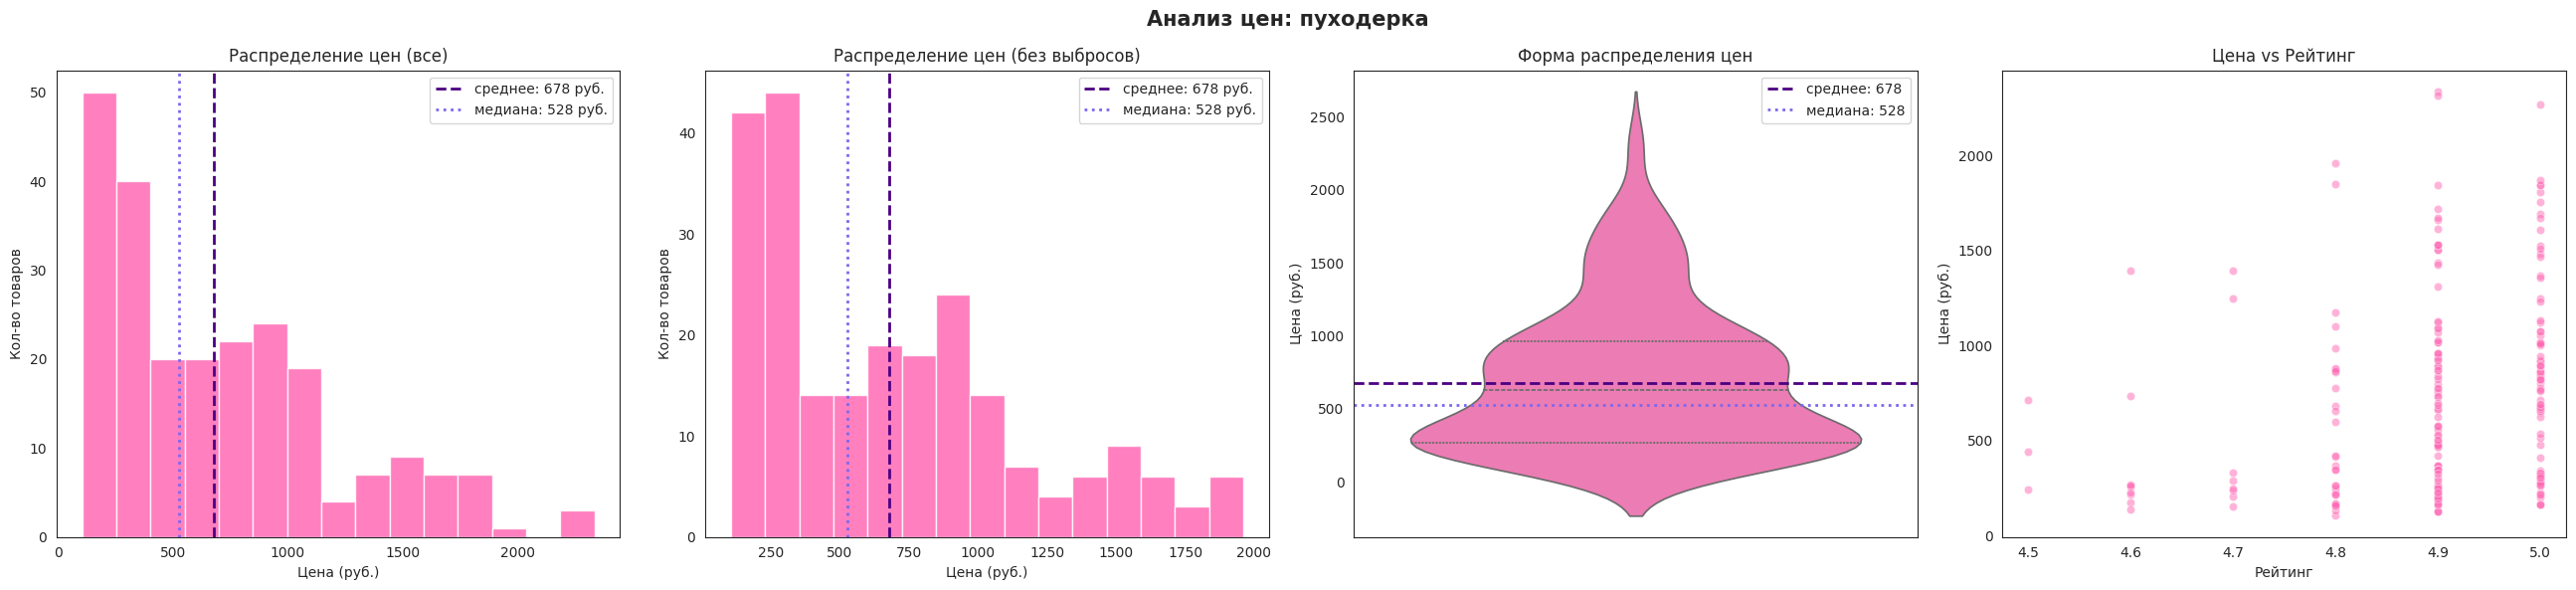

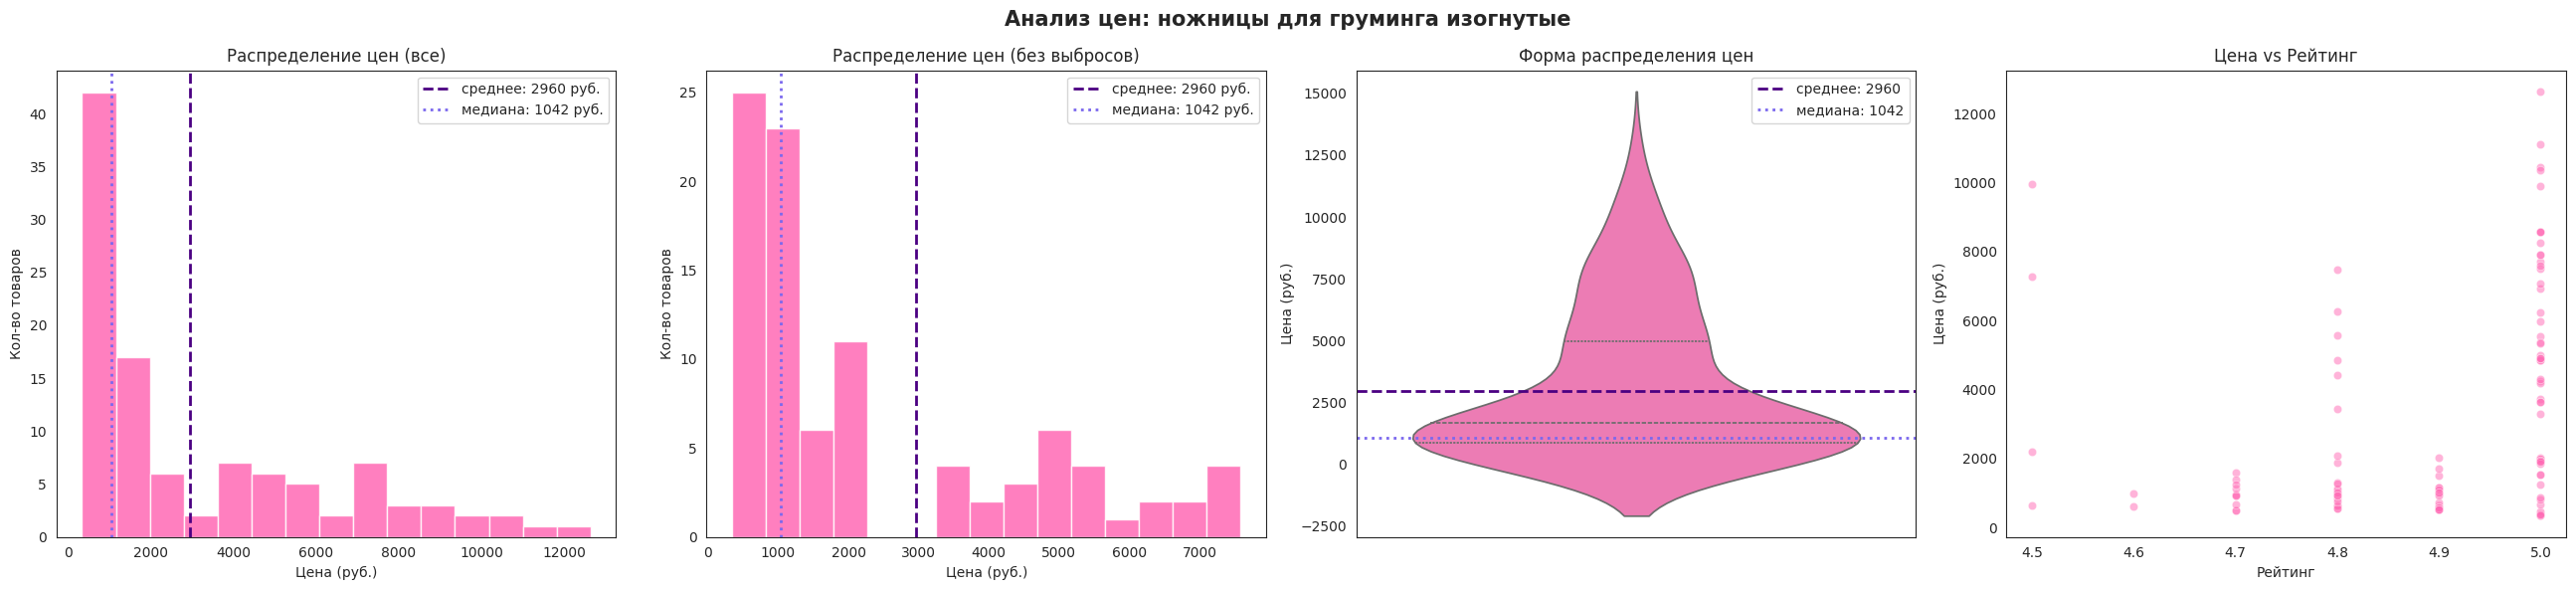

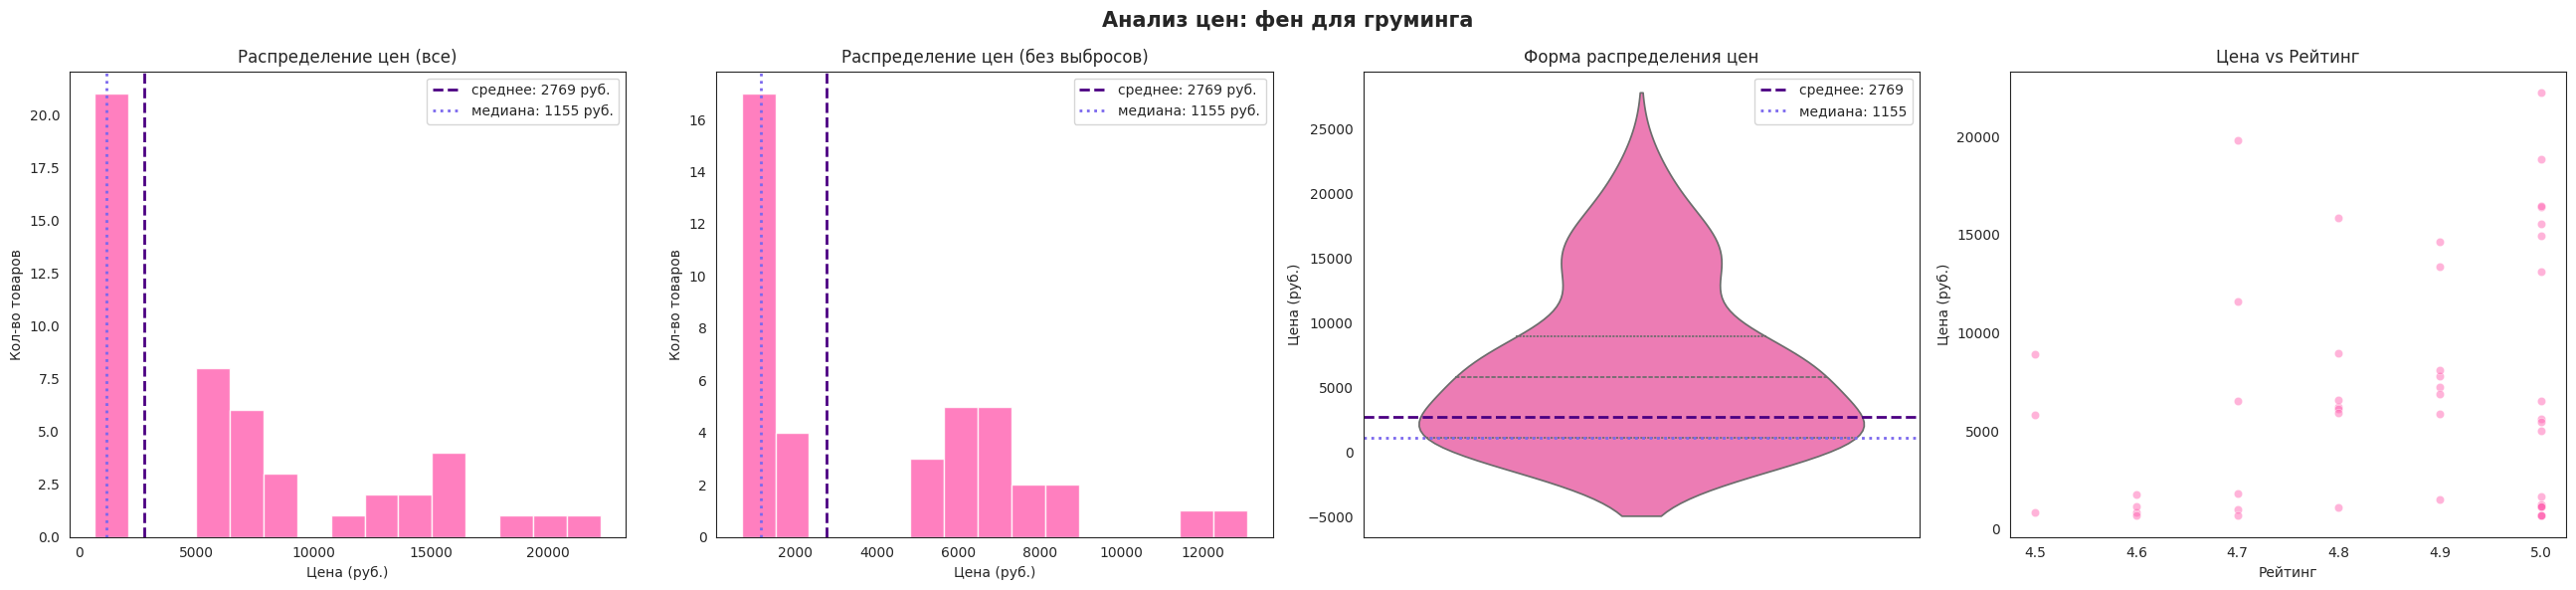

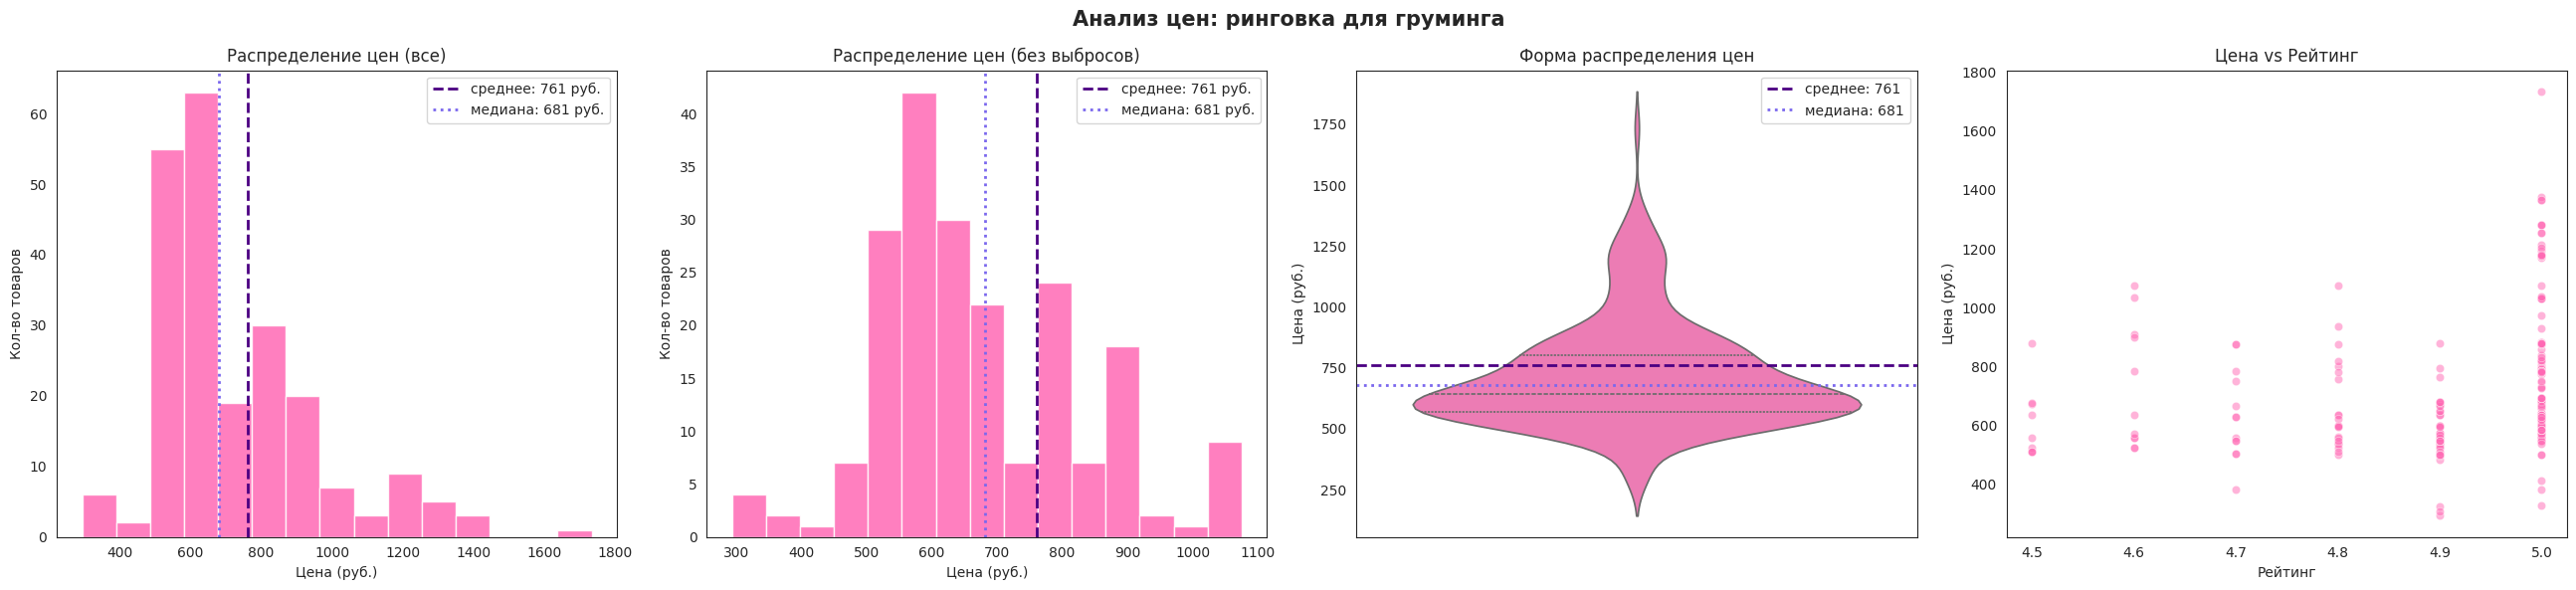

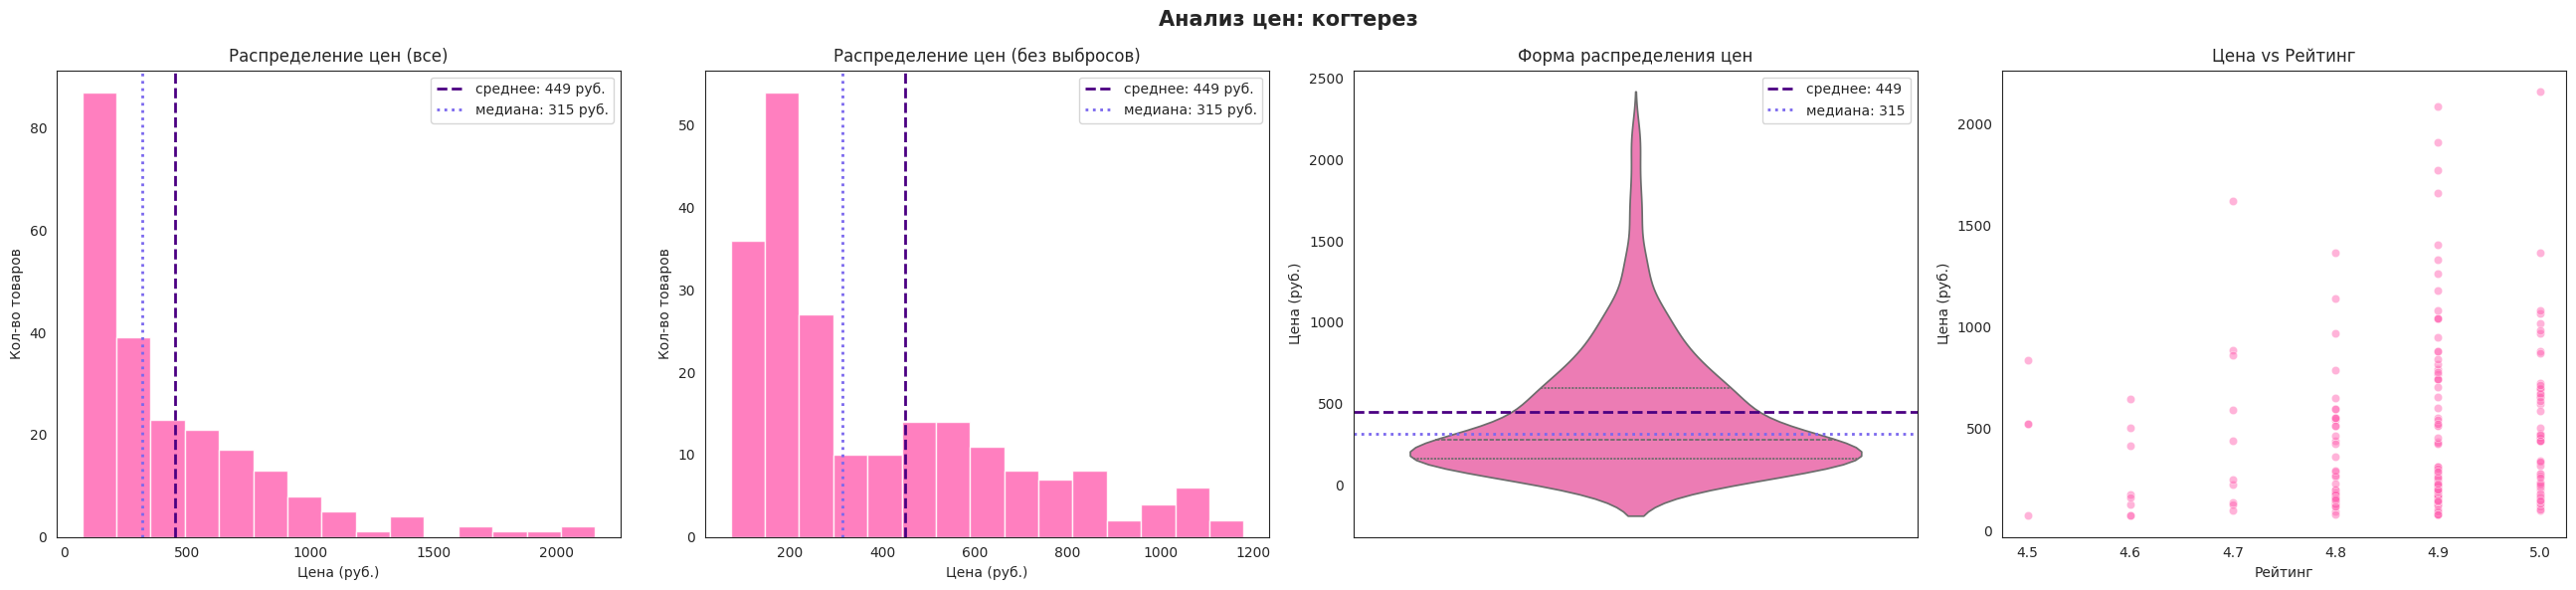

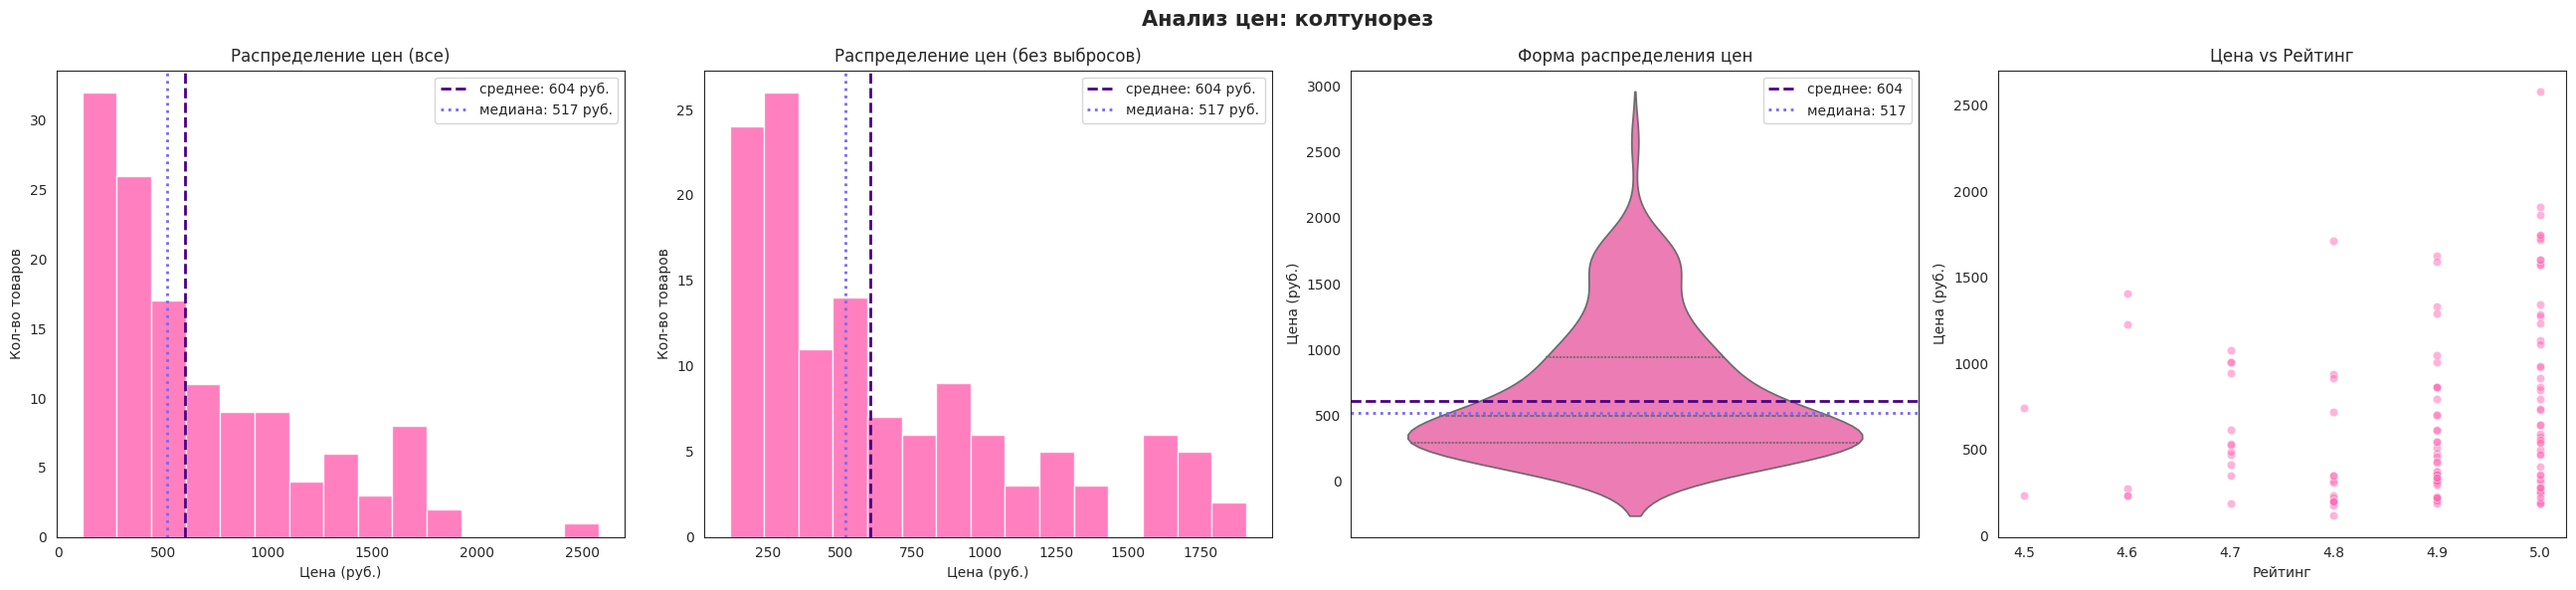

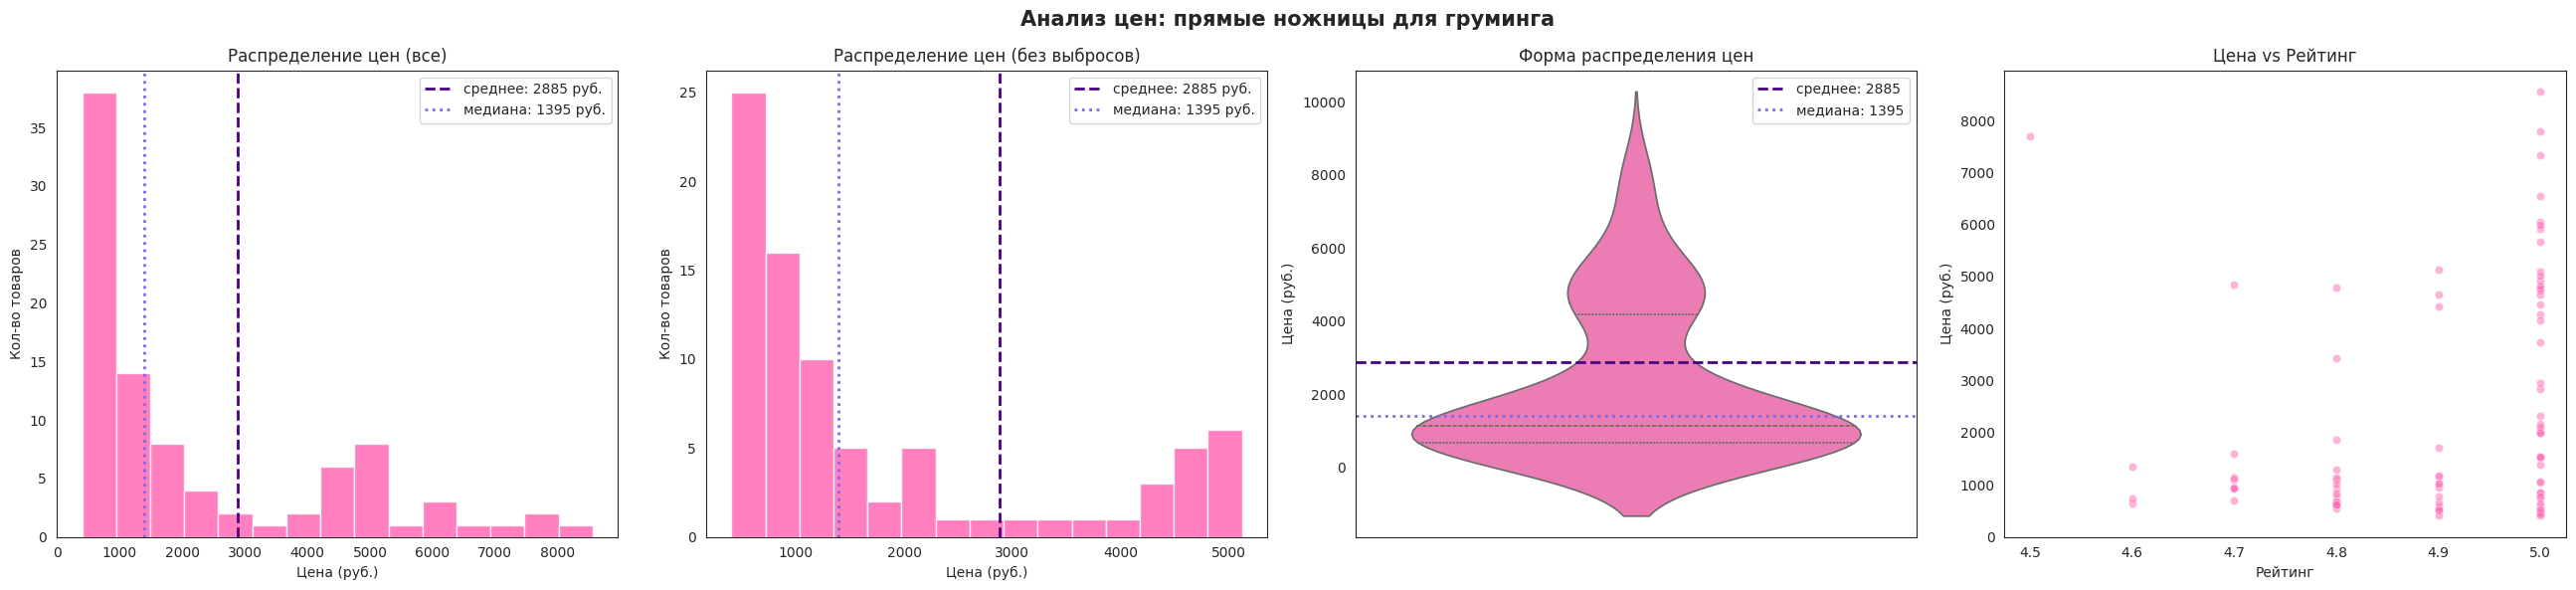

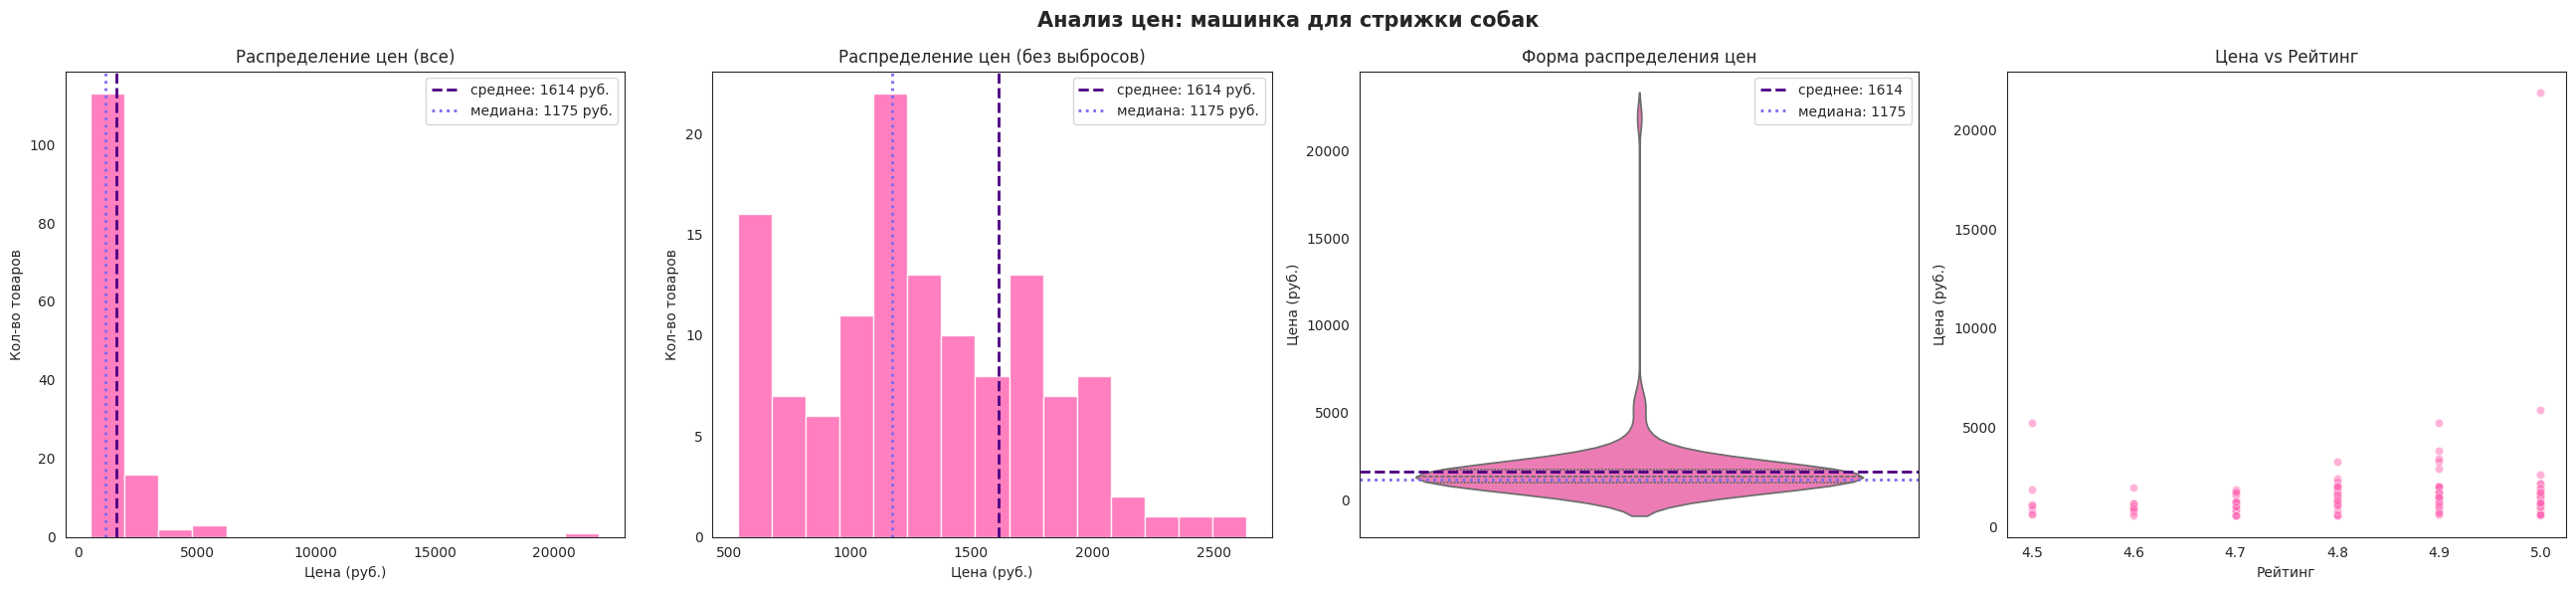

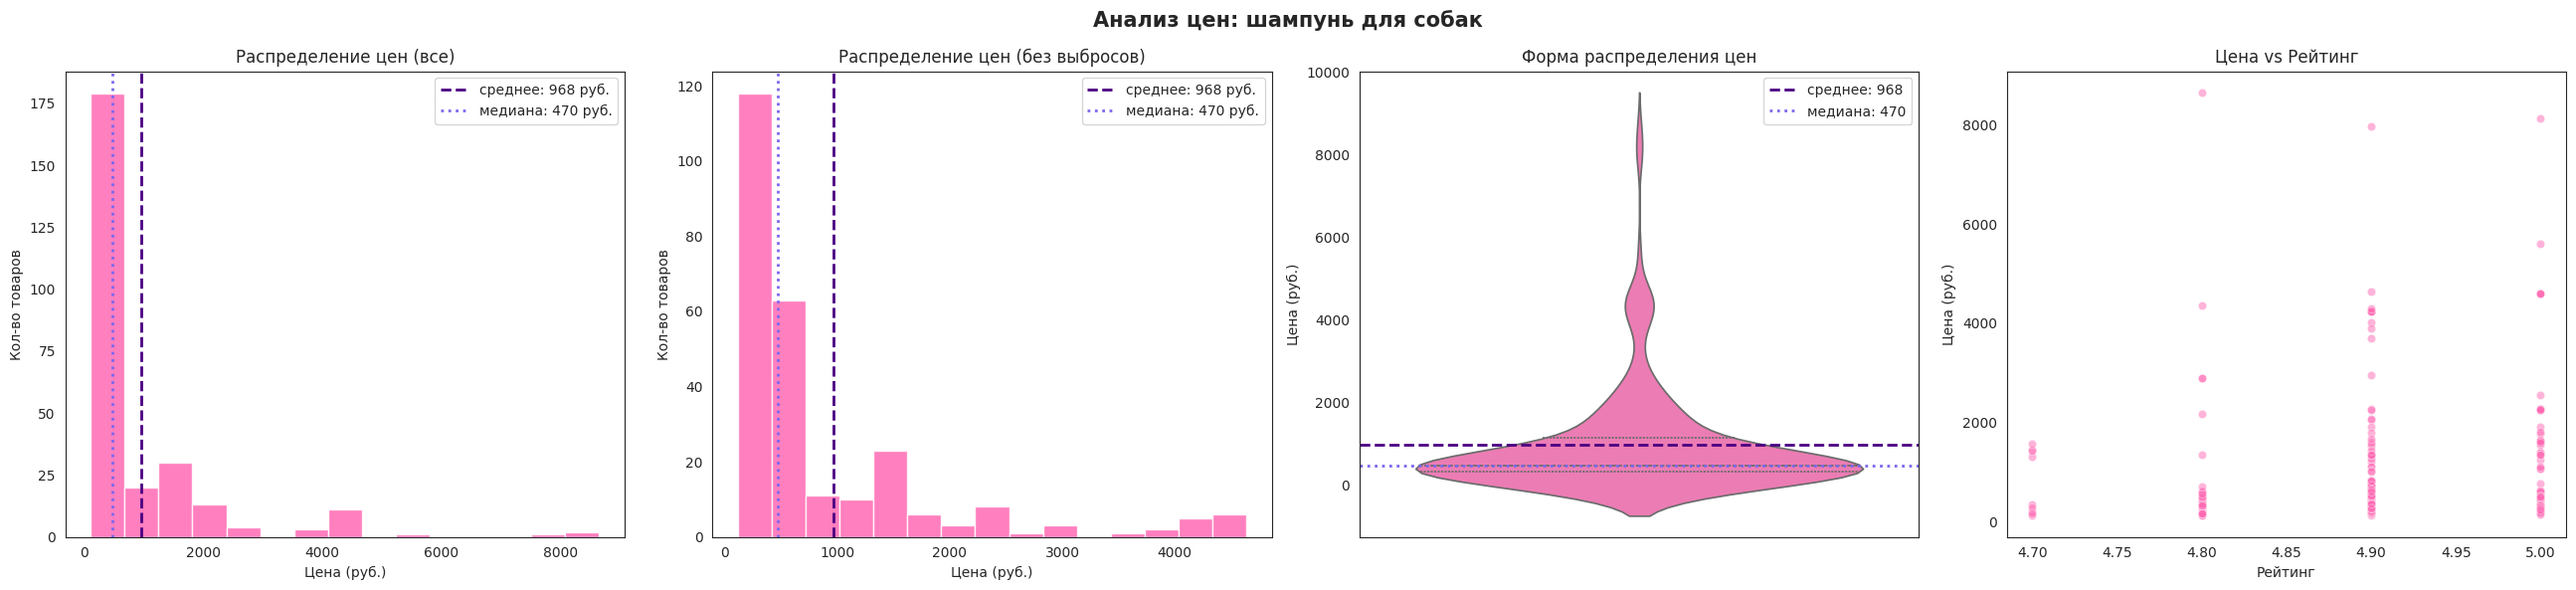

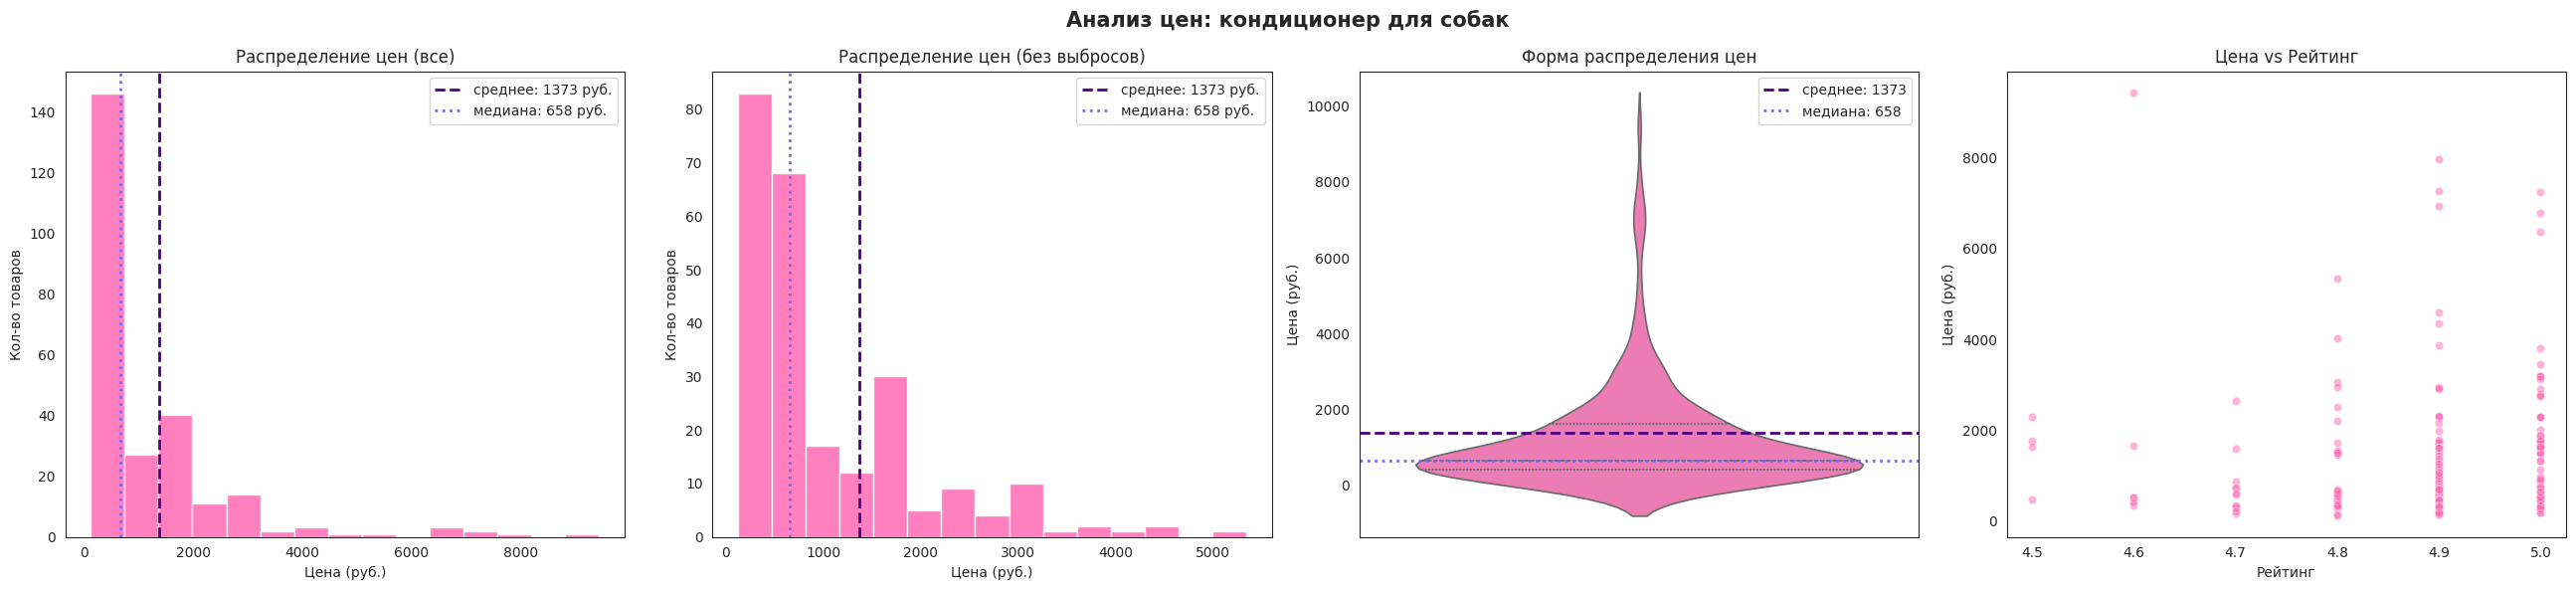

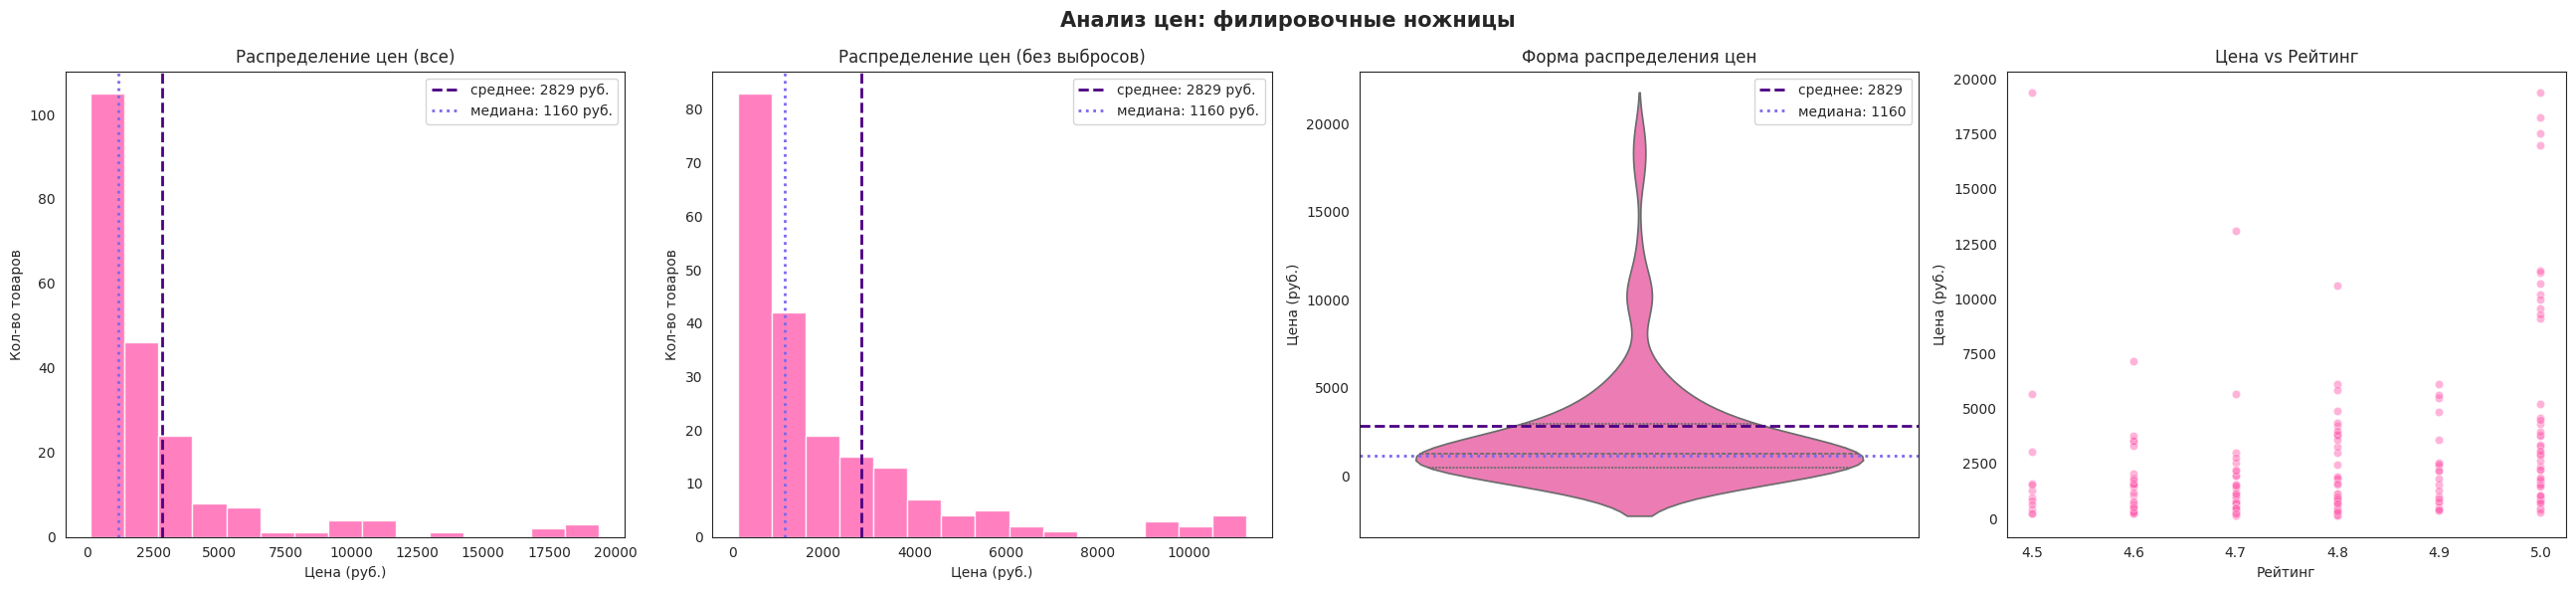

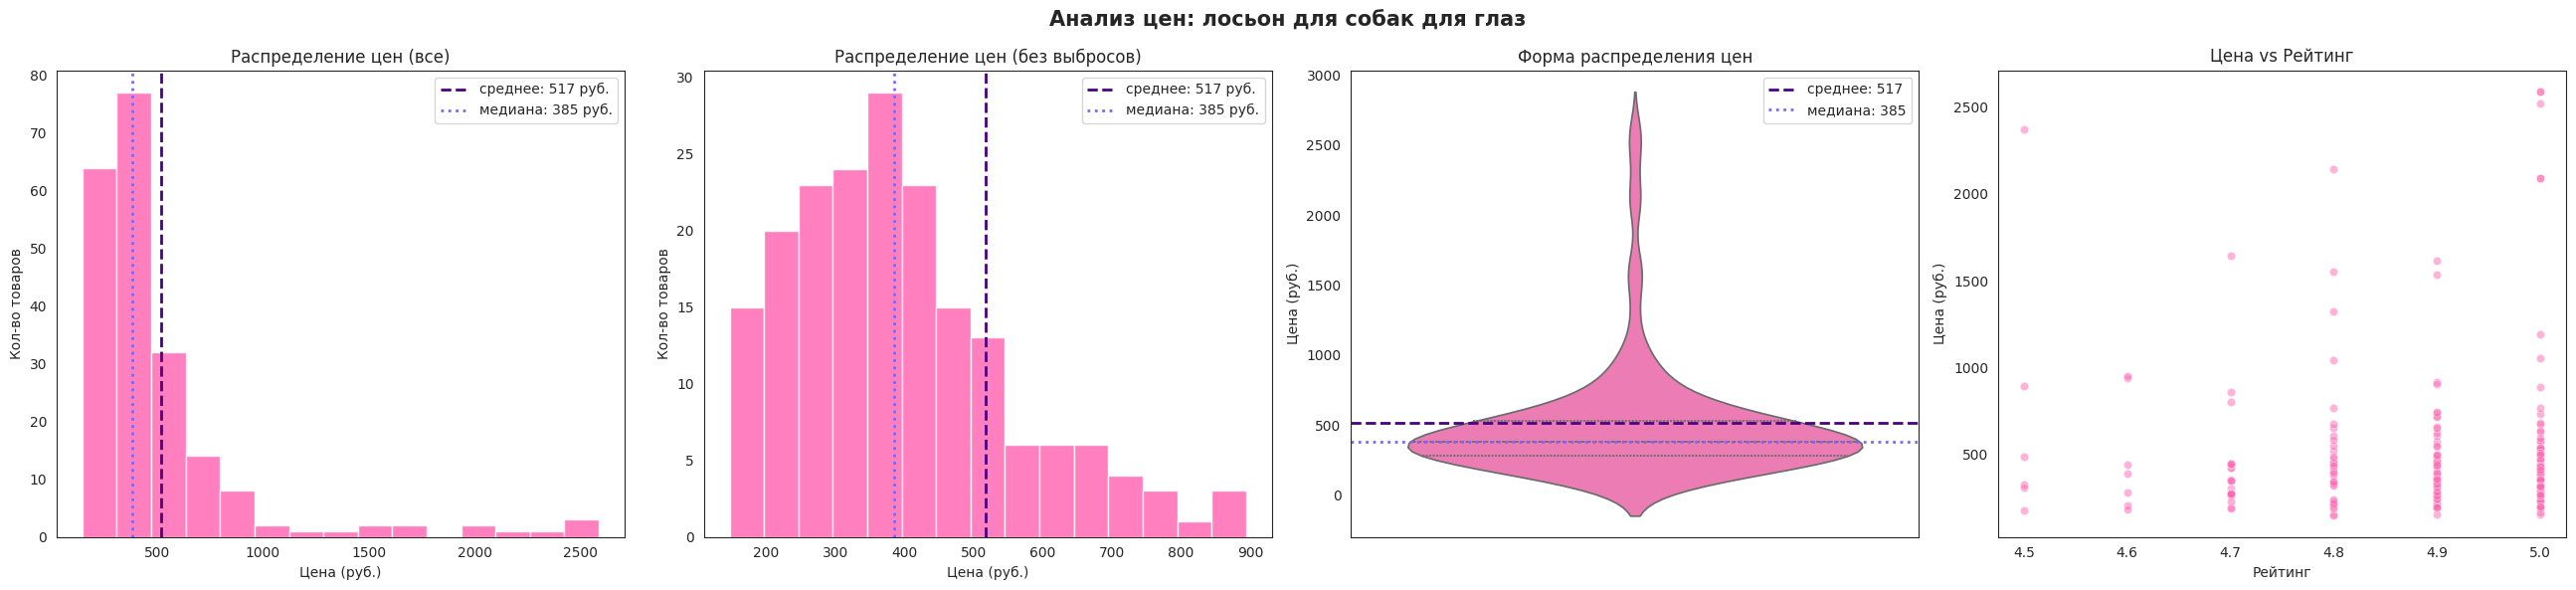

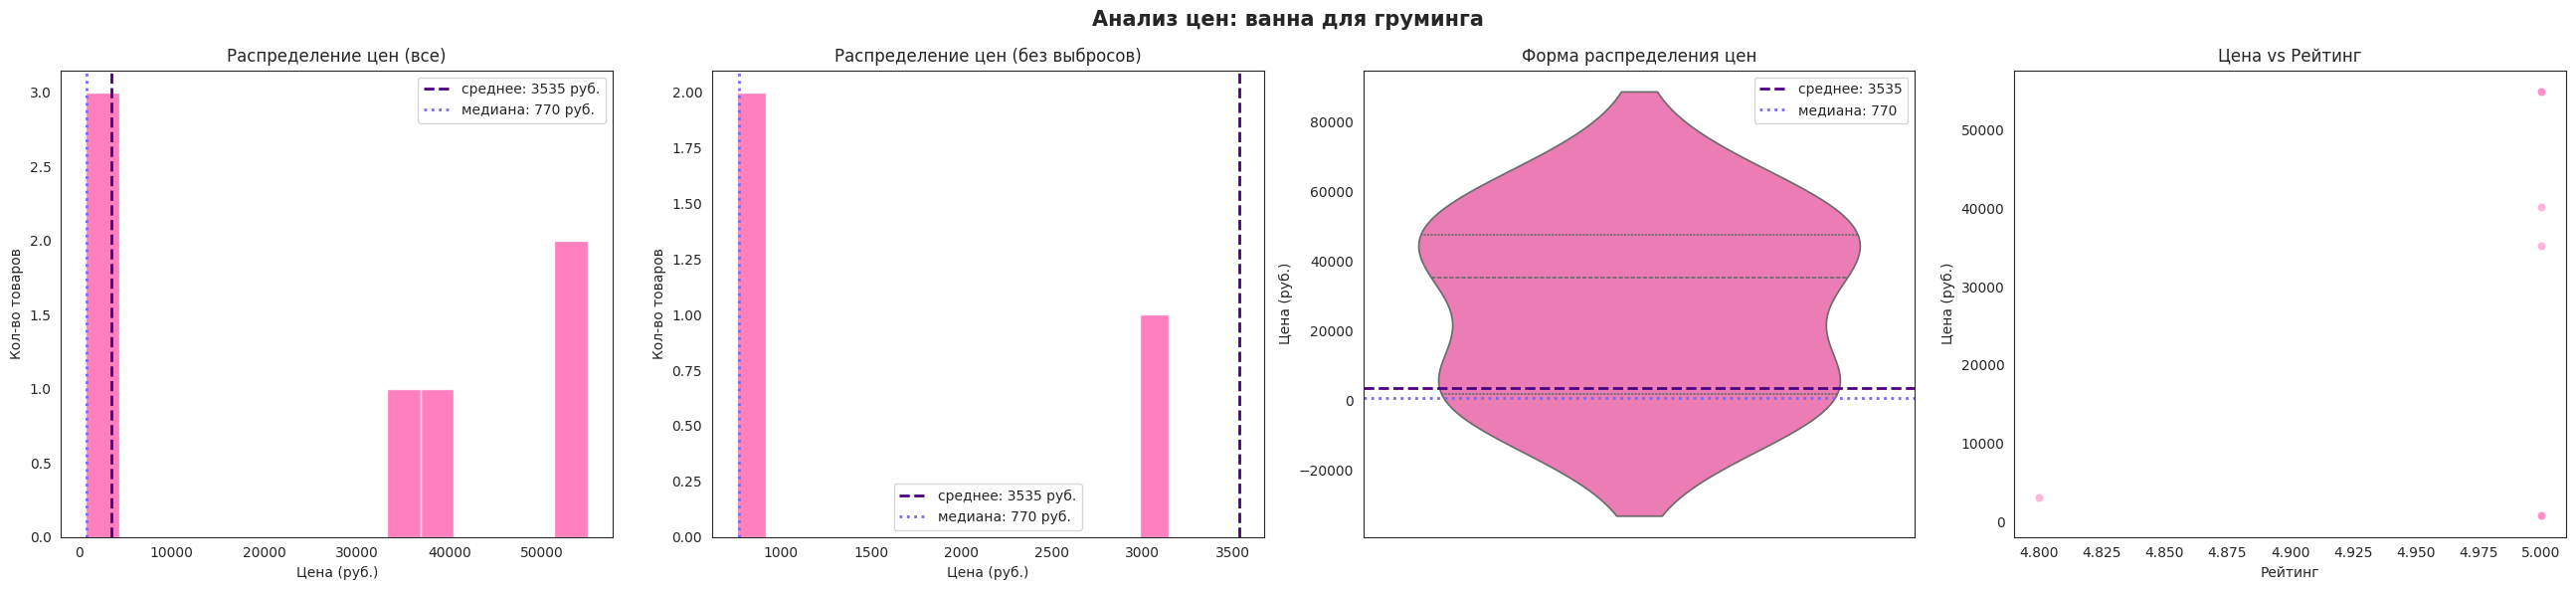

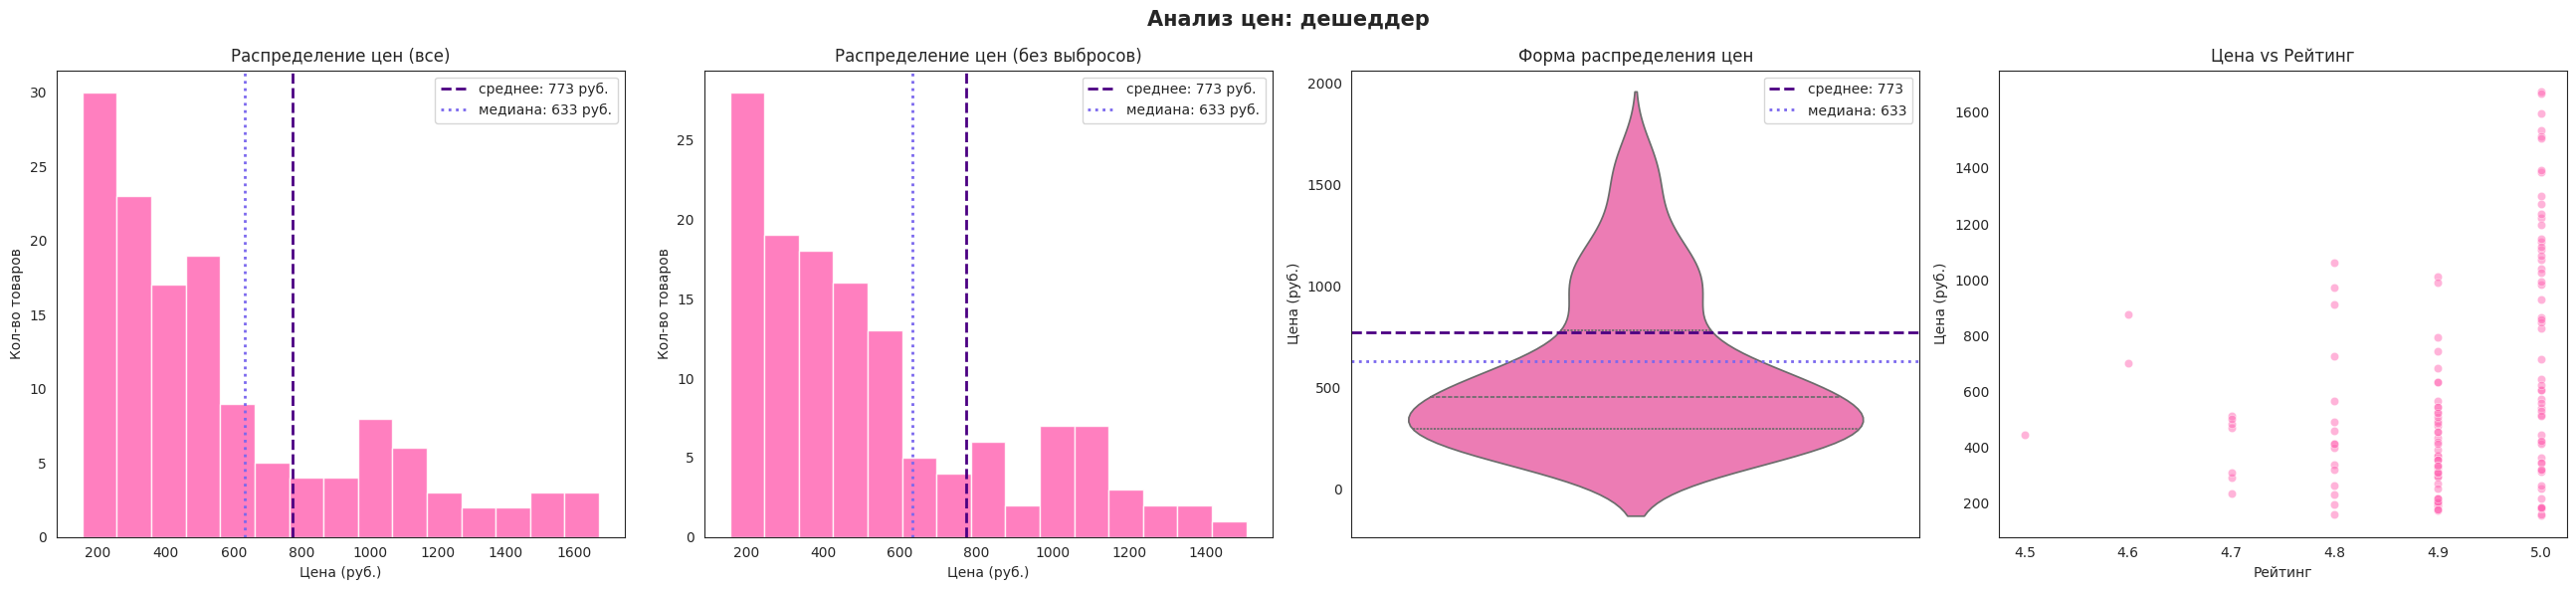

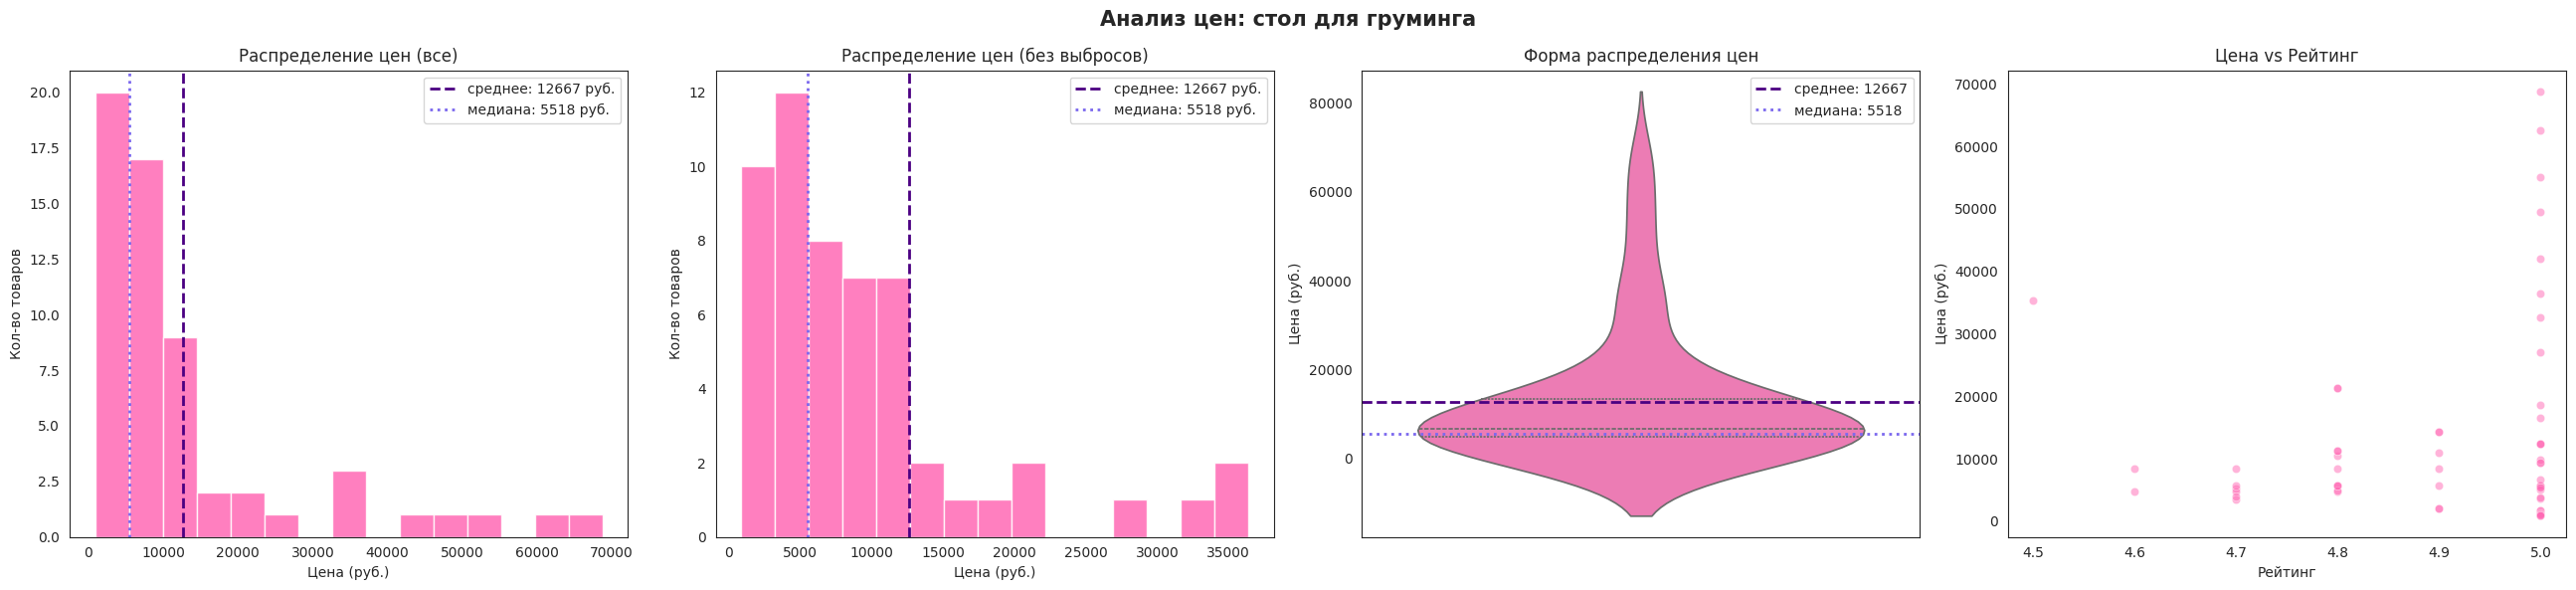

In [17]:
for var_name, query in GR.items():
    WBParser.create(var_name, query, permitted_words = PERMITTED[var_name])